In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,Age,Employment_Type,Years_of_Employment,Annual_Income,Savings_Balance,Bank_Balance,Credit_Score,Debt_to_Income_Ratio,Existing_Loans_Count,Loan_Amount_Requested,Loan_Term,Missed_Payments,Num_of_Credit_Inquiries,Credit_Card_Utilization,Residence_Type,Dependents_Count,Default
0,59,Salaried,4.446246,1777465,997150,472726,695,0.47,2,956030,12,0,3,19,Owned,4,0
1,49,Salaried,2.905413,803023,464710,415716,821,0.25,4,747247,24,2,8,83,Rented,1,0
2,35,Self-Employed,4.172893,952318,729992,119360,563,0.28,3,988397,36,5,9,35,Rented,4,0
3,28,Salaried,7.822088,1972508,269580,268894,573,0.32,0,924403,12,0,0,14,Rented,0,0
4,41,Salaried,6.488495,708434,348857,70018,471,0.46,0,498520,12,0,6,95,Owned,2,0


In [3]:
X = df.drop('Default', axis=1)
y = df['Default']


In [4]:
X = pd.get_dummies(X, drop_first=True)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
y_train.value_counts()


Default
0    1214
1     226
Name: count, dtype: int64

In [7]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [8]:
y_train_res.value_counts()

Default
0    1214
1    1214
Name: count, dtype: int64

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [10]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
y_pred = model.predict(X_test_scaled)

In [12]:
accuracy_score(y_test, y_pred)

0.8805555555555555

In [13]:
precision_score(y_test, y_pred)

0.5921052631578947

In [14]:
recall_score(y_test, y_pred)

0.7894736842105263

In [15]:
f1_score(y_test, y_pred)

0.6766917293233082

In [16]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[272  31]
 [ 12  45]]


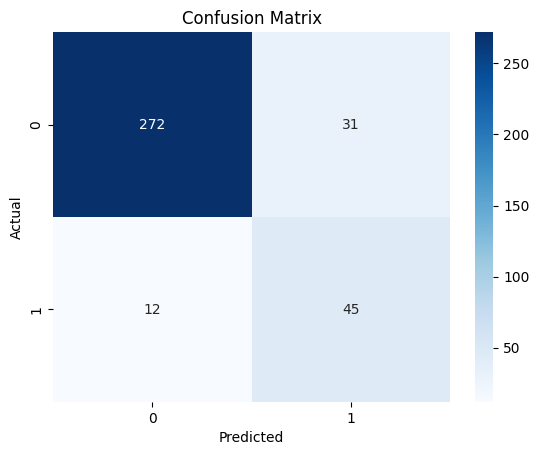

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       303
           1       0.59      0.79      0.68        57

    accuracy                           0.88       360
   macro avg       0.77      0.84      0.80       360
weighted avg       0.90      0.88      0.89       360



## Conclusion

- A Logistic Regression model was successfully built to predict loan default.
- SMOTE was used to handle class imbalance in the dataset.
- The model was evaluated using multiple performance metrics.
- The pipeline demonstrates a complete machine learning workflow from EDA to prediction.